# Exploratory Data Analysis: Marketing A/B Test

**Dataset**: [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)  
**Goal**: Compare frequentist and Bayesian approaches to analyzing this A/B test, including how each handles sequential monitoring ("peeking").

**Groups**:
- `ad`: users shown the marketing ad (564,577 users)
- `psa`: control group shown a public service announcement instead (23,524 users)

**Initial observation**: The `ad` group converts at ~2.55%, vs. ~1.79% for the `psa` group — a meaningful-looking lift on a fairly low base rate, with a notably unbalanced sample size between groups.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.shape

(588101, 7)

In [5]:
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [6]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [8]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


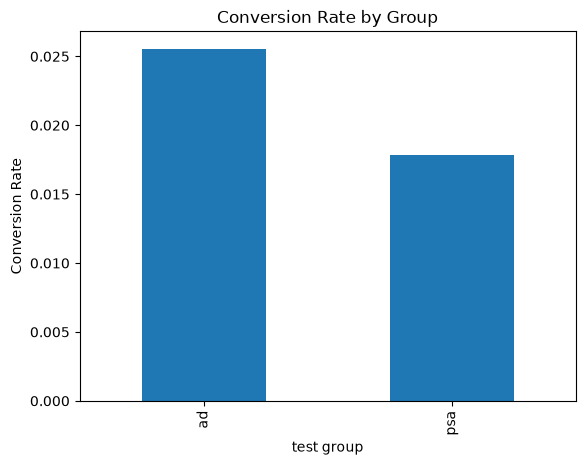

In [9]:
conversion_rates = df.groupby('test group')['converted'].mean()
conversion_rates.plot(kind='bar', title='Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.show()

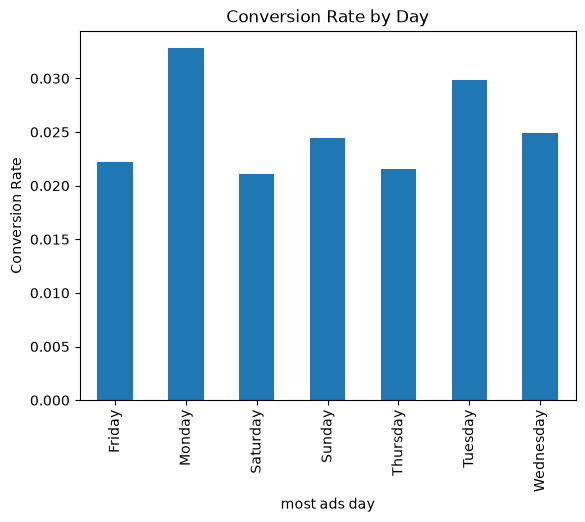

In [11]:
df.groupby('most ads day')['converted'].mean().plot(kind='bar', title='Conversion Rate by Day')
plt.ylabel('Conversion Rate')
plt.show()

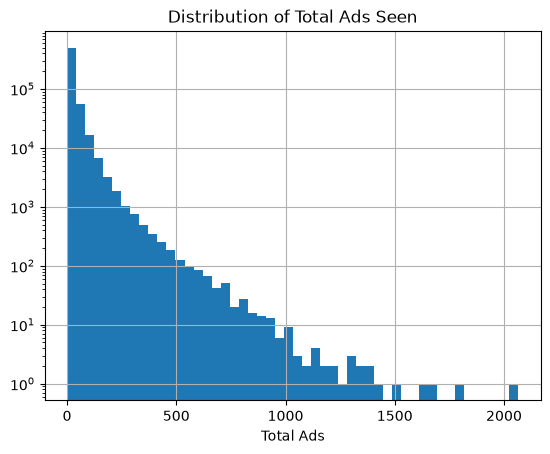

In [14]:
df['total ads'].hist(bins=50)
plt.yscale('log')
plt.title('Distribution of Total Ads Seen')
plt.xlabel('Total Ads')
plt.show()

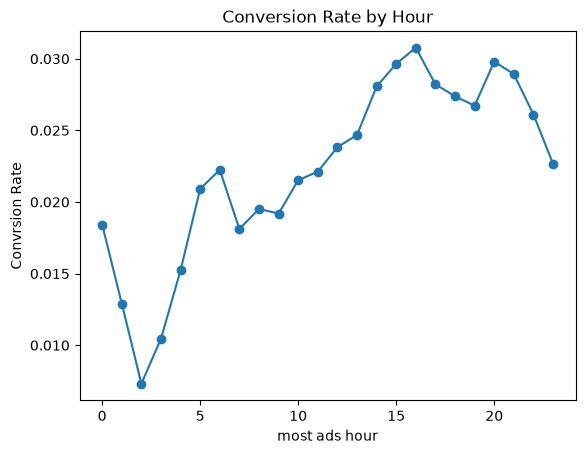

In [13]:
df.groupby('most ads hour')['converted'].mean().plot(kind='line', marker='o', title='Conversion Rate by Hour')
plt.ylabel('Convrsion Rate')
plt.show()

## Frequentist Analysis: Two-Proportion Z-Test

Testing whether the difference in conversion rates between `ad` and `psa` groups is statistically significant.

**H0**: conversion rate(ad) = conversion rate(psa)  
**H1**: conversion rate(ad) ≠ conversion rate(psa)

In [15]:
from statsmodels.stats.proportion import proportions_ztest

#Count of conversions and total observations per group
conversions = df.groupby('test group')['converted'].sum()
totals = df.groupby('test group')['converted'].count()

print(conversions)
print(totals)

test group
ad     14423
psa      420
Name: converted, dtype: int64
test group
ad     564577
psa     23524
Name: converted, dtype: int64


In [16]:
count = np.array([conversions['ad'], conversions['psa']])
nobs = np.array([totals['ad'], totals['psa']])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

Z-statistic: 7.3701
P-value: 0.0000000000


In [18]:
from statsmodels.stats.proportion import proportion_confint

#Confidence intervals for each group's conversion rate
ci_ad = proportion_confint(conversions['ad'], totals['ad'], alpha=0.05)
ci_psa = proportion_confint(conversions['psa'], totals['psa'], alpha=0.05)

print(f"Ad group 95% CI: {ci_ad}")
print(f"PSA group 95% CI: {ci_psa}")

Ad group 95% CI: (0.0251349995427061, 0.025958119730661394)
PSA group 95% CI: (0.016161914715211324, 0.019546298173753137)


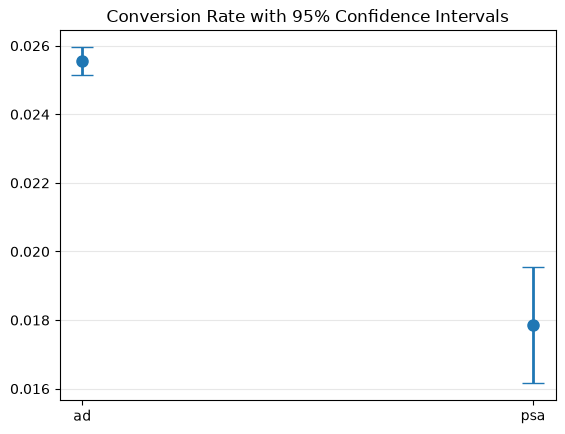

In [19]:
groups = ['ad', 'psa']
rates = [rate_ad if 'rate_ad' in dir() else conversions['ad']/totals['ad'],
        rate_psa if 'rate_psa' in dir() else conversions['psa']/totals['psa']]
ci_lower = [ci_ad[0], ci_psa[0]]
ci_upper = [ci_ad[1], ci_psa[1]]
errors = [[rates[i] - ci_lower[i] for i in range(2)], [ci_upper[i] - rates[i] for i in range(2)]]

plt.errorbar(groups, rates, yerr=errors, fmt='o', capsize=8, markersize=8, linewidth=2)
plt.title('Conversion Rate with 95% Confidence Intervals')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [21]:
rate_ad = conversions['ad'] / totals['ad']
rate_psa = conversions['psa'] / totals['psa']
relative_lift = (rate_ad - rate_psa) / rate_psa

print(f"Ad conversion rate: {rate_ad:.4f}")
print(f"PSA conversion rate: {rate_psa:.4f}")
print(f"Relative lift: {relative_lift:.2%}")

Ad conversion rate: 0.0255
PSA conversion rate: 0.0179
Relative lift: 43.09%


## Frequentist Summary

- Z-test result: z = 7.37, p < 0.0001 → statistically significant difference in conversion rates
- Ad group: 2.55% (95% CI: 2.51%–2.60%)
- PSA group: 1.79% (95% CI: 1.62%–1.95%)
- Relative lift: ~43% higher conversion rate for the ad group
- Confidence intervals do not overlap, reinforcing the significance finding
- Note: PSA group's wider interval reflects its much smaller sample size (23,524 vs 564,577)